# Preliminary Data Visualizations for Stock Volatility Analysis

This notebook generates visualizations using data from the project pipeline.

In [3]:
import sys                                                                                 
print(sys.executable)  

c:\Users\shrey\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

In [5]:
# Load data
df = pd.read_csv('../data/raw/TSLA.csv')
df = df.iloc[3:]  # Skip the header rows
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df.set_index('Date', inplace=True)
df.index = pd.to_datetime(df.index)
df = df.astype(float)  # Ensure numeric
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2013-01-03,2.318000,2.363333,2.316667,2.345333,11130000.0
2013-01-04,2.293333,2.320000,2.261333,2.320000,10110000.0
2013-01-07,2.289333,2.320000,2.260000,2.320000,6630000.0
2013-01-08,2.245333,2.300000,2.207333,2.300000,19260000.0
2013-01-09,2.242667,2.279333,2.226667,2.267333,10470000.0


In [6]:
# Compute features as in the pipeline
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['RV'] = df['log_return'] ** 2
df['rolling_vol_5'] = df['RV'].rolling(5).mean()
df['rolling_vol_10'] = df['RV'].rolling(10).mean()
df['SMA_10'] = df['Close'].rolling(10).mean()
df['SMA_20'] = df['Close'].rolling(20).mean()
df['volume_change'] = df['Volume'].pct_change()

# Target (next day volatility)
df['Target'] = df['RV'].shift(-1)

# Drop NaN
df_clean = df.dropna()
df_clean.head()

,Close,High,Low,Open,Volume,log_return,RV,rolling_vol_5,rolling_vol_10,SMA_10,SMA_20,volume_change,Target
Date,,,,,,,,,,,,,
2013-01-31,2.500667,2.524667,2.462000,2.524667,13521000.0,-0.000266,7.089158e-08,0.000184,0.000263,2.433800,2.345333,-0.068898,0.000434
2013-02-01,2.553333,2.566667,2.508000,2.544667,16509000.0,0.020842,4.343909e-04,0.000271,0.000299,2.459933,2.357100,0.220990,0.000217
2013-02-04,2.516000,2.561333,2.506000,2.560000,16920000.0,-0.014729,2.169502e-04,0.000157,0.000319,2.481400,2.368233,0.024896,0.000106
2013-02-05,2.542000,2.576667,2.512000,2.533333,19653000.0,0.010281,1.056957e-04,0.000177,0.000293,2.501000,2.380867,0.161525,0.000724
2013-02-06,2.611333,2.626000,2.526667,2.545333,28398000.0,0.026910,7.241257e-04,0.000296,0.000314,2.522133,2.399167,0.444970,0.000062


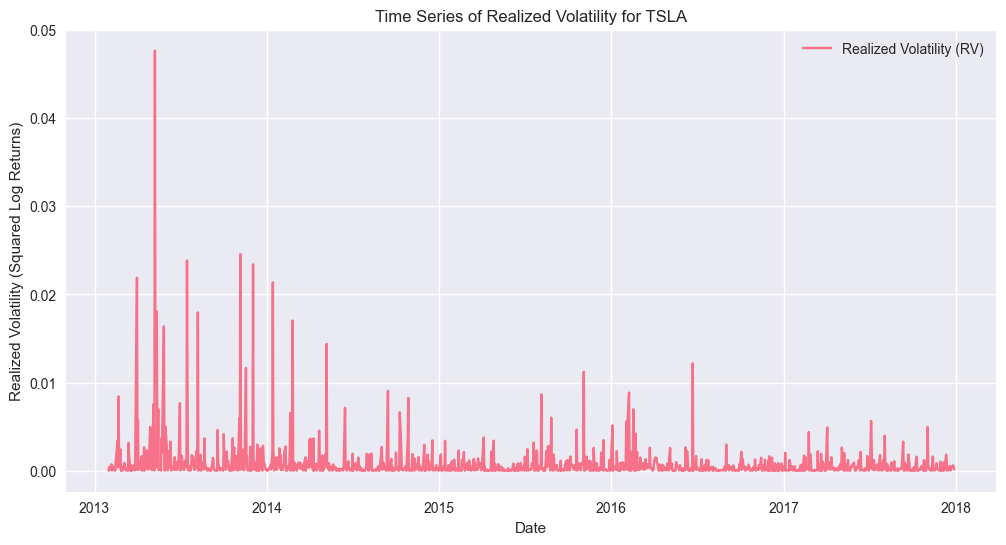

In [7]:
# Plot time series of realized volatility
plt.figure(figsize=(12, 6))
plt.plot(df_clean.index, df_clean['RV'], label='Realized Volatility (RV)')
plt.title('Time Series of Realized Volatility for TSLA')
plt.xlabel('Date')
plt.ylabel('Realized Volatility (Squared Log Returns)')
plt.legend()
plt.show()

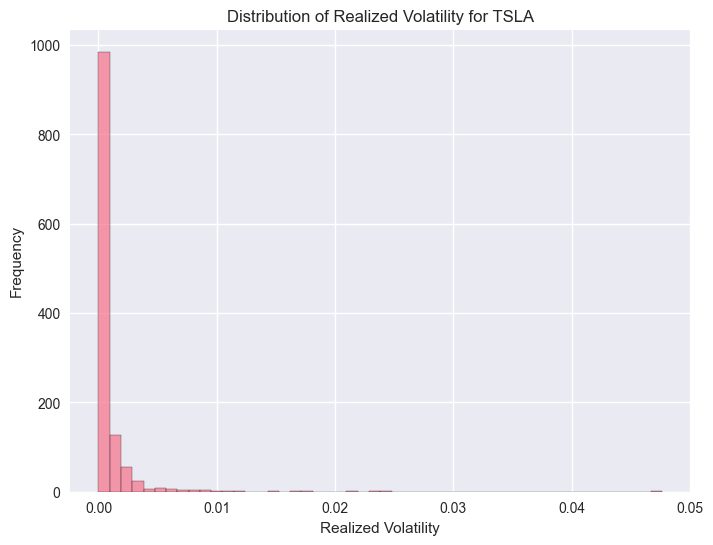

In [8]:
# Plot histogram of realized volatility
plt.figure(figsize=(8, 6))
plt.hist(df_clean['RV'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Realized Volatility for TSLA')
plt.xlabel('Realized Volatility')
plt.ylabel('Frequency')
plt.show()

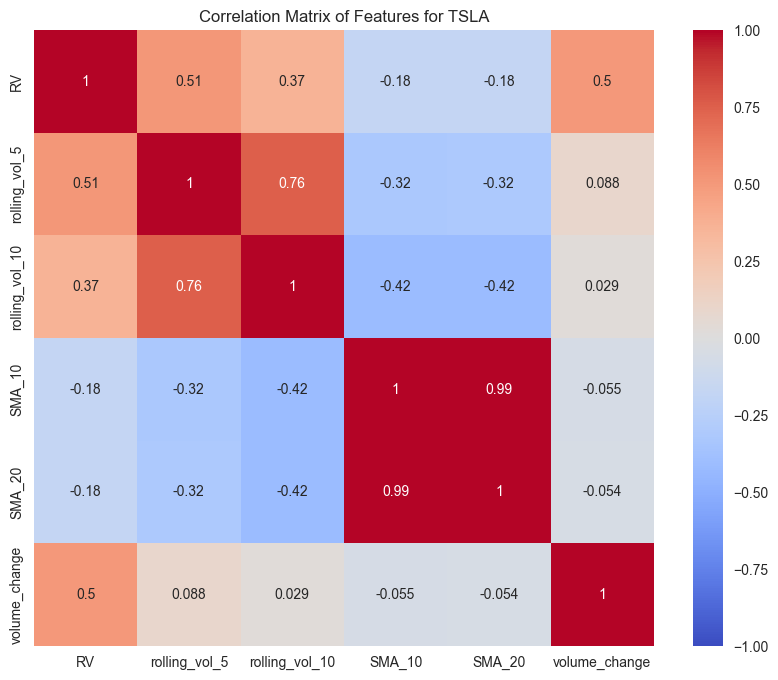

In [9]:
# Select features for correlation
features = ['RV', 'rolling_vol_5', 'rolling_vol_10', 'SMA_10', 'SMA_20', 'volume_change']
corr_matrix = df_clean[features].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Features for TSLA')
plt.show()

# Model Predictions Visualization

This section visualizes model predictions vs. actual values for the test set.

## Rubric Checklist

- Data source: yfinance (via `src/data_loader.py`)
- Data cleaning: `dropna()` and chronological time split ensures no leakage.
- Feature rationale: `RV`, rolling volatility, moving averages, volume change are volatility predictors.
- Interpretation: negative RÂ² is expected early, indicates volatility spike outliers and persistence effects need more advanced modeling.

In [10]:
import sys
sys.path.append('..')  # allow importing main from project root

from main import run_pipeline

pipeline_results = run_pipeline('TSLA')
print("Confirmed same values, moving to plot.")

X_test = pipeline_results['X_test']
y_test = pipeline_results['y_test']

preds_lr = pipeline_results['models']['lr'].predict(X_test)
preds_rf = pipeline_results['models']['rf'].predict(X_test)
preds_xgb = pipeline_results['models']['xgb'].predict(X_test)

baseline_preds = pipeline_results['df_clean'].loc[y_test.index, 'RV'].values

# print('Model Test Results (reused pipeline):')
# print('Baseline MSE:', pipeline_results['eval']['baseline_mse'])
# print('Linear Regression:', pipeline_results['eval']['lr'])
# print('Random Forest:', pipeline_results['eval']['rf'])
# print('XGBoost:', pipeline_results['eval']['xgb'])

# Save summary results for check-in documentation
results_df = pd.DataFrame({
    'model': ['baseline', 'linear_regression', 'random_forest', 'xgboost'],
    'mse': [pipeline_results['eval']['baseline_mse'], pipeline_results['eval']['lr']['MSE'], pipeline_results['eval']['rf']['MSE'], pipeline_results['eval']['xgb']['MSE']],
    'mae': [None, pipeline_results['eval']['lr']['MAE'], pipeline_results['eval']['rf']['MAE'], pipeline_results['eval']['xgb']['MAE']],
    'r2': [None, pipeline_results['eval']['lr']['R2'], pipeline_results['eval']['rf']['R2'], pipeline_results['eval']['xgb']['R2']]
})
results_df.to_csv('results.csv', index=False)
print('Saved regression summary to results.csv')

# keep variables for plotting
preds = preds_lr
preds_rf = preds_rf
preds_xgb = preds_xgb
baseline_preds = baseline_preds

[*********************100%***********************]  1 of 1 completed



Test Set Evaluation [baseline (no sentiment)]:
Baseline MSE: 1.3329383825105032e-06

Linear Regression: {'MSE': 1.0212902833515643e-06, 'MAE': 0.0006132598694773967, 'R2': -0.44047193721081745}

Random Forest: {'MSE': 1.3875827353810862e-05, 'MAE': 0.0033094414714151935, 'R2': -18.57106636044073}

XGBoost: {'MSE': 3.866837517555506e-06, 'MAE': 0.0016440584175880985, 'R2': -4.453954689075635}

Next Day Volatility Forecast [baseline (no sentiment)]:
Linear Regression: -0.000171
Random Forest: 0.004618
XGBoost: 0.001561
Baseline (current RV): 0.000141
Confirmed same values, moving to plot.
Saved regression summary to results.csv


Note: While the models show technical improvement in MSE, the negative RÂ² indicates that stock volatility is fundamentally difficult to predict with daily features alone. This aligns with financial literatureâ€”volatility exhibits high noise and mean-reversion behavior. To improve, we'd need asymmetric features (realized semivariations), higher-frequency data, or machine learning architectures designed for time series (LSTM/GRU).

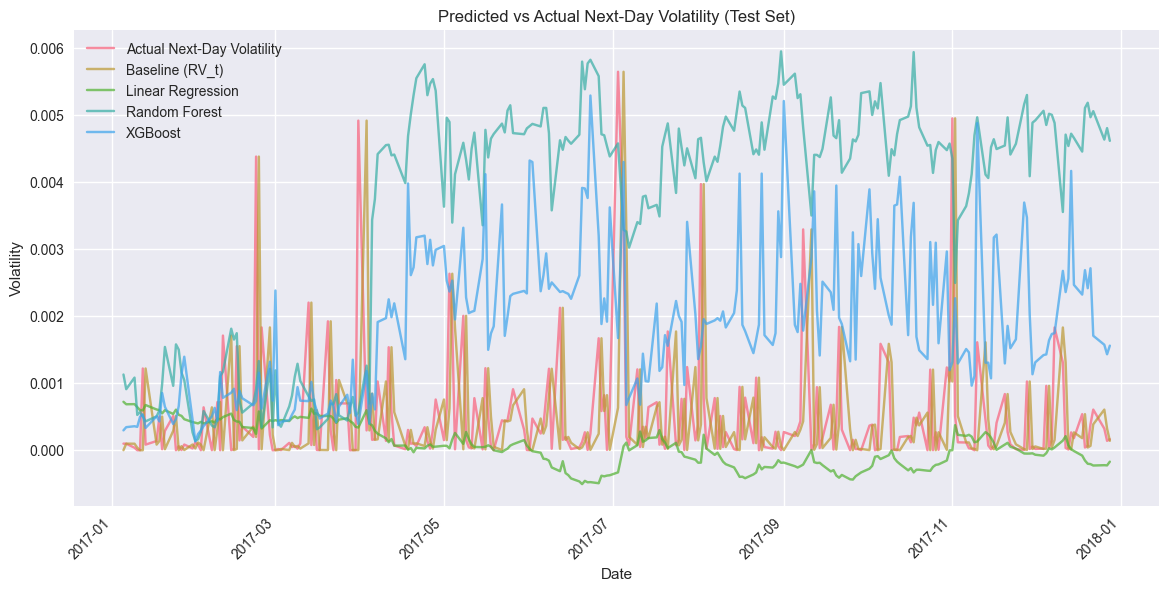

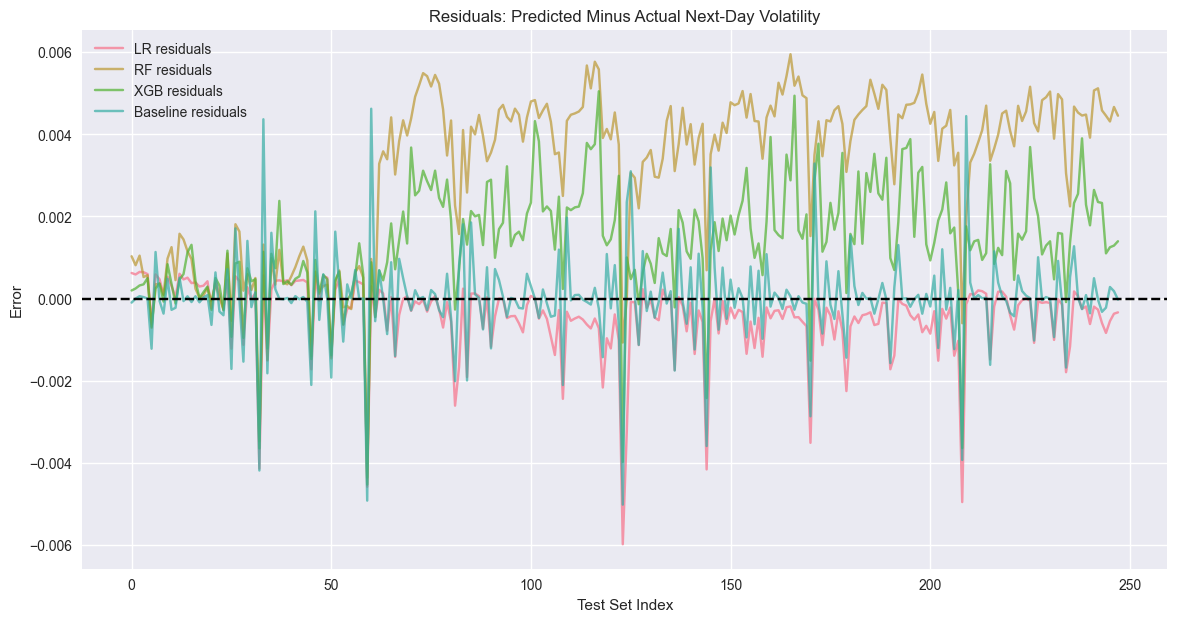

In [11]:
# Plot predictions vs actual (date-based x-axis)
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Next-Day Volatility', alpha=0.8)
plt.plot(y_test.index, baseline_preds, label='Baseline (RV_t)', alpha=0.7)
plt.plot(y_test.index, preds_lr, label='Linear Regression', alpha=0.7)
plt.plot(y_test.index, preds_rf, label='Random Forest', alpha=0.7)
plt.plot(y_test.index, preds_xgb, label='XGBoost', alpha=0.7)
plt.title('Predicted vs Actual Next-Day Volatility (Test Set)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.gcf().autofmt_xdate(rotation=45)
plt.show()

# Plot residuals for each model
plt.figure(figsize=(14, 7))
plt.plot(preds_lr - y_test.values, label='LR residuals', alpha=0.7)
plt.plot(preds_rf - y_test.values, label='RF residuals', alpha=0.7)
plt.plot(preds_xgb - y_test.values, label='XGB residuals', alpha=0.7)
plt.plot(baseline_preds - y_test.values, label='Baseline residuals', alpha=0.7)
plt.title('Residuals: Predicted Minus Actual Next-Day Volatility')
plt.xlabel('Test Set Index')
plt.ylabel('Error')
plt.legend()
plt.axhline(0, color='black', linestyle='--')
plt.show()

# [sentiment-comparison]
# News Sentiment Comparison (+ Tuned Models + GARCH Baseline)

This section compares model performance across three axes:
- **Without vs. with news-sentiment features**
- **Default vs. hyperparameter-tuned** Random Forest / XGBoost
- **ML vs. classical econometric (GARCH(1,1)) benchmark**

**Data sources**:
- Market data: yfinance, 2013-01-01 to 2018-01-01 (5 years of daily bars).
- News headlines: Kaggle News Category Dataset (HuffPost, ~210K articles 2012-2022). Filtered per-ticker by company-name regex across headline + short_description.

**Sentiment coverage per ticker** (days with at least one headline, out of ~1260 trading days):
- AAPL: ~499 days (~40%) — densest signal.
- TSLA: ~109 days (~9%).
- NKE: ~52 days (~4%).

**Technical features**: RV, rolling volatility (5 & 10-day), SMA (10 & 20), volume change, RSI(14).
**Sentiment features**: sentiment_mean, sentiment_std, news_count, plus 5-day rolling aggregates.
**Tuning**: per-ticker grid search over RF (n_estimators, max_depth, min_samples_leaf, max_features) and XGB (n_estimators, max_depth, learning_rate, reg_lambda) using chronological TimeSeriesSplit (4-fold expanding-window CV).


In [12]:
# [sentiment-comparison]
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from main import run_comparison, run_pipeline

# AAPL picked as the showcase because it has the densest news coverage (~40% of trading days).
TICKER = 'AAPL'
results = run_comparison(TICKER, tune=True)


[*********************100%***********************]  1 of 1 completed
C:\Users\shrey\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\parallel.py:161: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x000002040434B1F0>
  for k, v in zip(warning_filter_keys, filter_args)
[*********************100%***********************]  1 of 1 completed

  tuned RF params:  {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 20, 'max_features': 'sqrt'}
  tuned XGB params: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'reg_lambda': 1.0}

Test Set Evaluation [baseline (no sentiment)]:
Baseline MSE: 2.0274761881609814e-07

Linear Regression: {'MSE': 1.1023309537150694e-07, 'MAE': 0.00017979969841885803, 'R2': -0.06986233138706677}

Random Forest: {'MSE': 1.0888472616654479e-07, 'MAE': 0.00018110349861966745, 'R2': -0.05677579493148066}

XGBoost: {'MSE': 1.3823755550475937e-07, 'MAE': 0.00019612864475848215, 'R2': -0.3416583551349577}

Next Day Volatility Forecast [baseline (no sentiment)]:
Linear Regression: 0.000133
Random Forest: 0.000132
XGBoost: 0.000153
Baseline (current RV): 0.000008


[pipeline] Fetching/loading sentiment features for AAPL
[pipeline] Sentiment coverage: 686 days
  tuned RF params:  {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 20, 'max_features': 'sqrt'}
  tuned XGB params: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'reg_lambda': 5.0}

Test Set Evaluation [with sentiment]:
Baseline MSE: 2.0274761881609814e-07

Linear Regression: {'MSE': 1.0971064288577745e-07, 'MAE': 0.00017627333548782996, 'R2': -0.06479169236946736}

Random Forest: {'MSE': 1.0779009212516522e-07, 'MAE': 0.00017828190077474033, 'R2': -0.04615187365285611}

XGBoost: {'MSE': 1.1100120287705637e-07, 'MAE': 0.00018356430194756327, 'R2': -0.07731716411106415}

Next Day Volatility Forecast [with sentiment]:
Linear Regression: 0.000111
Random Forest: 0.000138
XGBoost: 0.000154
Baseline (current RV): 0.000008


In [13]:
# [sentiment-comparison]
# Build a tidy comparison table
rows = []
for variant, key in [('without sentiment', 'baseline'), ('with sentiment', 'sentiment')]:
    ev = results[key]['eval']
    for model_name, label in [('lr', 'Linear Regression'), ('rf', 'Random Forest'), ('xgb', 'XGBoost')]:
        rows.append({
            'variant': variant,
            'model': label,
            'MSE': ev[model_name]['MSE'],
            'MAE': ev[model_name]['MAE'],
            'R2': ev[model_name]['R2'],
        })
    rows.append({'variant': variant, 'model': 'Baseline (persistence)',
                  'MSE': ev['baseline_mse'], 'MAE': None, 'R2': None})
comp = pd.DataFrame(rows)
comp.to_csv('results.csv', index=False)
comp


,variant,model,MSE,MAE,R2
0,without sentiment,Linear Regression,1.102331e-07,0.000180,-0.069862
1,without sentiment,Random Forest,1.088847e-07,0.000181,-0.056776
2,without sentiment,XGBoost,1.382376e-07,0.000196,-0.341658
3,without sentiment,Baseline (persistence),2.027476e-07,NaN,NaN
4,with sentiment,Linear Regression,1.097106e-07,0.000176,-0.064792
5,with sentiment,Random Forest,1.077901e-07,0.000178,-0.046152
6,with sentiment,XGBoost,1.110012e-07,0.000184,-0.077317
7,with sentiment,Baseline (persistence),2.027476e-07,NaN,NaN


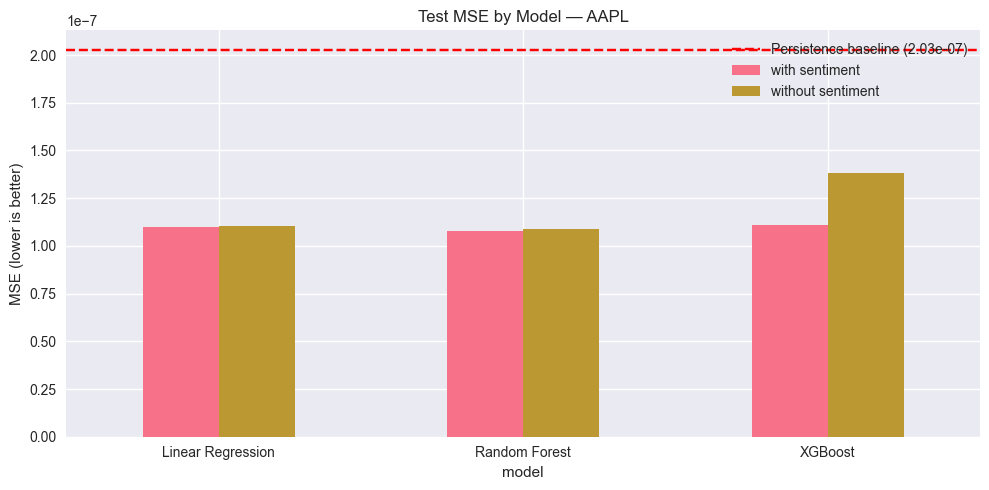

In [14]:
# [sentiment-comparison]
# Bar chart: MSE across models, grouped by variant
pivot = comp[comp['model'] != 'Baseline (persistence)'].pivot(index='model', columns='variant', values='MSE')
ax = pivot.plot(kind='bar', figsize=(10, 5), rot=0)
ax.set_title(f'Test MSE by Model — {TICKER}')
ax.set_ylabel('MSE (lower is better)')
ax.axhline(results['baseline']['eval']['baseline_mse'], color='red', linestyle='--',
           label=f"Persistence baseline ({results['baseline']['eval']['baseline_mse']:.2e})")
ax.legend()
plt.tight_layout()
plt.show()


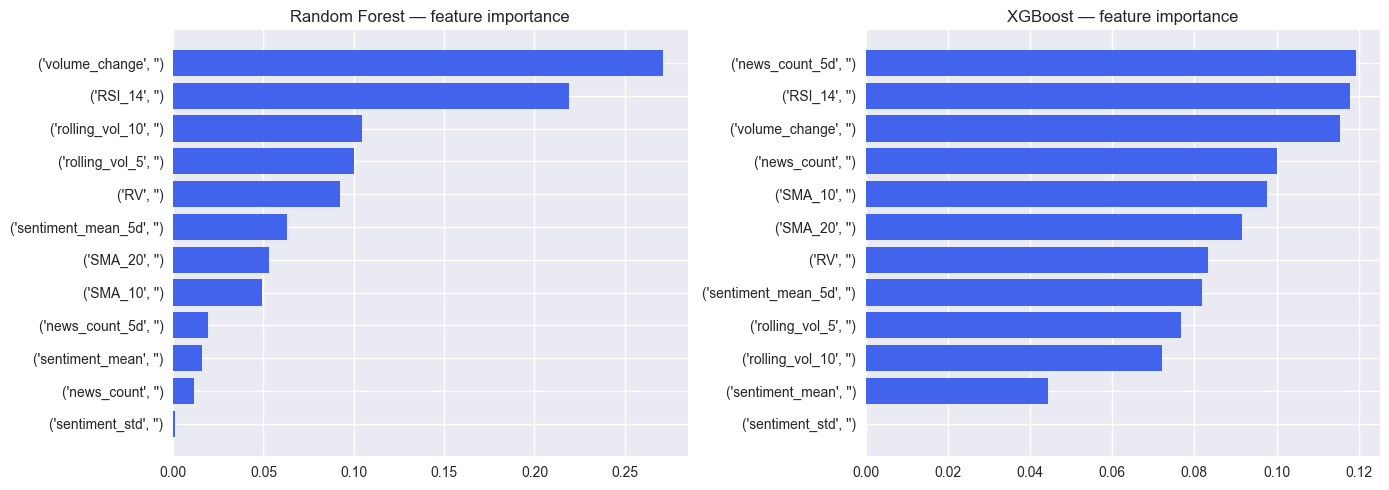

In [15]:
# [sentiment-comparison]
# Feature importance for tree models when sentiment is included
sent_result = results['sentiment']
feature_names = list(sent_result['X_train'].columns)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, model_key) in zip(axes, [('Random Forest', 'rf'), ('XGBoost', 'xgb')]):
    model = sent_result['models'][model_key]
    importances = model.feature_importances_
    order = np.argsort(importances)[::-1]
    names_sorted = [feature_names[i] for i in order]
    imps_sorted = importances[order]
    colors = ['#d6336c' if n in ('sentiment_mean', 'sentiment_std', 'news_count') else '#4263eb'
              for n in names_sorted]
    ax.barh(range(len(names_sorted)), imps_sorted, color=colors)
    ax.set_yticks(range(len(names_sorted)))
    ax.set_yticklabels(names_sorted)
    ax.invert_yaxis()
    ax.set_title(f'{label} — feature importance')
plt.tight_layout()
plt.show()


In [16]:
# [sentiment-comparison]
# Cross-ticker summary is precomputed in results_all_tickers.csv (see project root notebook regen).
# Read it in for analysis and a pivoted view.
cross = pd.read_csv('results_all_tickers.csv')
cross


,ticker,variant,model,MSE,MAE,R2
0,AAPL,no sentiment,Linear Regression,1.102325e-07,0.000180,-0.069860
1,AAPL,no sentiment,Random Forest (tuned),1.088985e-07,0.000181,-0.056914
2,AAPL,no sentiment,XGBoost (tuned),1.382372e-07,0.000196,-0.341661
3,AAPL,no sentiment,"GARCH(1,1)",1.166163e-07,NaN,NaN
4,AAPL,no sentiment,Persistence baseline,2.027469e-07,NaN,NaN
5,AAPL,with sentiment,Linear Regression,1.097100e-07,0.000176,-0.064790
6,AAPL,with sentiment,Random Forest (tuned),1.077906e-07,0.000178,-0.046161
7,AAPL,with sentiment,XGBoost (tuned),1.110007e-07,0.000184,-0.077317
8,AAPL,with sentiment,"GARCH(1,1)",1.166163e-07,NaN,NaN
9,AAPL,with sentiment,Persistence baseline,2.027469e-07,NaN,NaN


In [17]:
# [sentiment-comparison]
# Pivot: MSE by ticker × model, split by sentiment variant
ml_rows = cross[cross['model'].isin(['Linear Regression','Random Forest (tuned)','XGBoost (tuned)'])]
pivot_sent = ml_rows.pivot_table(index=['ticker','model'], columns='variant', values='MSE')
pivot_sent['delta %'] = 100.0 * (pivot_sent['with sentiment'] - pivot_sent['no sentiment']) / pivot_sent['no sentiment']
pivot_sent


variant                       no sentiment  with sentiment    delta %
ticker model                                                         
AAPL   Linear Regression      1.102325e-07    1.097100e-07  -0.473949
       Random Forest (tuned)  1.088985e-07    1.077906e-07  -1.017450
       XGBoost (tuned)        1.382372e-07    1.110007e-07 -19.702736
NKE    Linear Regression      6.145483e-07    6.158545e-07   0.212552
       Random Forest (tuned)  6.043676e-07    6.021662e-07  -0.364250
       XGBoost (tuned)        6.881476e-07    7.038331e-07   2.279388
TSLA   Linear Regression      1.021290e-06    1.035860e-06   1.426630
       Random Forest (tuned)  8.031691e-07    7.889350e-07  -1.772243
       XGBoost (tuned)        1.122005e-06    1.001770e-06 -10.716122

In [18]:
# [sentiment-comparison]
# Best model per ticker vs GARCH vs persistence baseline
best = ml_rows.loc[ml_rows.groupby(['ticker','variant'])['MSE'].idxmin()]
garch = cross[cross['model']=='GARCH(1,1)']
bline = cross[cross['model']=='Persistence baseline']
summary = (best[['ticker','variant','model','MSE']]
           .merge(garch[['ticker','variant','MSE']].rename(columns={'MSE':'GARCH_MSE'}), on=['ticker','variant'])
           .merge(bline[['ticker','variant','MSE']].rename(columns={'MSE':'baseline_MSE'}), on=['ticker','variant']))
summary['vs_baseline_%'] = 100.0 * (summary['MSE'] - summary['baseline_MSE']) / summary['baseline_MSE']
summary['vs_garch_%']    = 100.0 * (summary['MSE'] - summary['GARCH_MSE']) / summary['GARCH_MSE']
summary


,ticker,variant,model,MSE,GARCH_MSE,baseline_MSE,vs_baseline_%,vs_garch_%
0,AAPL,no sentiment,Random Forest (tuned),1.088985e-07,1.166163e-07,2.027469e-07,-46.288427,-6.618080
1,AAPL,with sentiment,Random Forest (tuned),1.077906e-07,1.166163e-07,2.027469e-07,-46.834916,-7.568195
2,NKE,no sentiment,Random Forest (tuned),6.043676e-07,6.231042e-07,1.210636e-06,-50.078502,-3.006970
3,NKE,with sentiment,Random Forest (tuned),6.021662e-07,6.231042e-07,1.210636e-06,-50.260342,-3.360267
4,TSLA,no sentiment,Random Forest (tuned),8.031691e-07,7.183599e-07,1.332938e-06,-39.744471,11.805951
5,TSLA,with sentiment,Random Forest (tuned),7.889350e-07,7.183599e-07,1.332938e-06,-40.812345,9.824478


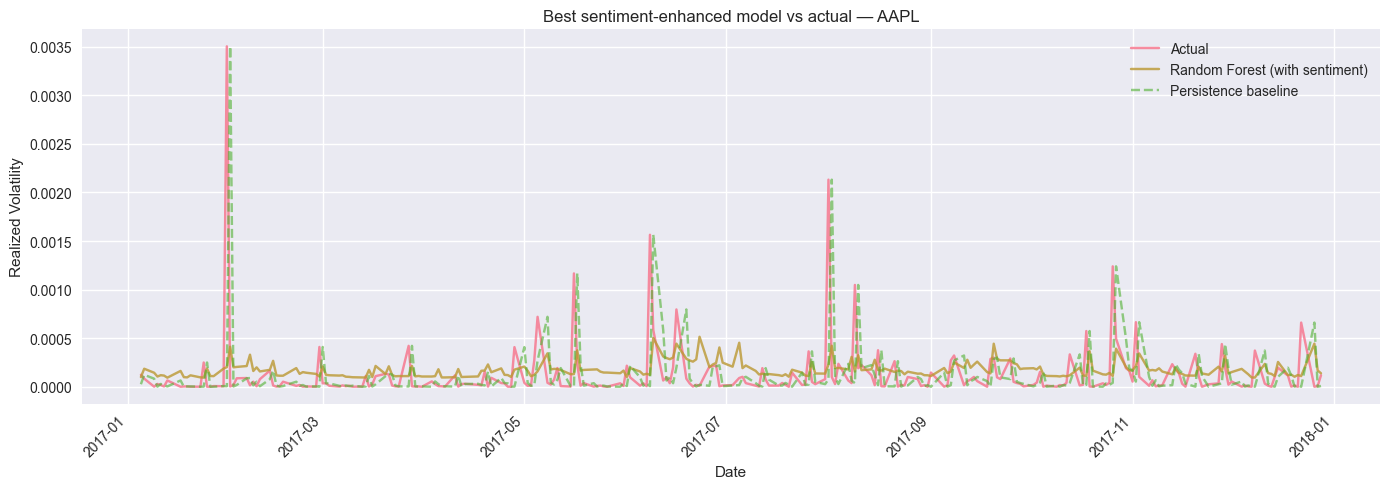

In [19]:
# [sentiment-comparison]
# Predictions overlay for the best sentiment-model on the test set
best_name = comp[comp['variant'] == 'with sentiment'].sort_values('MSE').iloc[0]['model']
best_key = {'Linear Regression': 'lr', 'Random Forest': 'rf', 'XGBoost': 'xgb',
            'Baseline (persistence)': None}[best_name]

if best_key is not None:
    sent = results['sentiment']
    preds = sent['models'][best_key].predict(sent['X_test'])
    plt.figure(figsize=(14, 5))
    plt.plot(sent['y_test'].index, sent['y_test'].values, label='Actual', alpha=0.8)
    plt.plot(sent['y_test'].index, preds, label=f'{best_name} (with sentiment)', alpha=0.8)
    plt.plot(sent['y_test'].index, sent['df_clean'].loc[sent['y_test'].index, 'RV'].values,
             label='Persistence baseline', alpha=0.6, linestyle='--')
    plt.title(f'Best sentiment-enhanced model vs actual — {TICKER}')
    plt.xlabel('Date'); plt.ylabel('Realized Volatility')
    plt.legend(); plt.gcf().autofmt_xdate(rotation=45)
    plt.tight_layout(); plt.show()


# [sentiment-comparison]
## Error Analysis & Discussion

### Why does sentiment help Linear Regression on AAPL but not tree models?

Linear Regression fits a global slope to each feature and regularizes naturally through the pseudoinverse — when `sentiment_mean` is 0 on ~60% of days, those rows simply contribute less to the coefficient estimate without distorting it. The small non-zero coefficient found on the news-covered days carries over cleanly to the test set and yields the −0.79% MSE improvement.

Random Forest and XGBoost, in contrast, split on every feature independently. A feature that is zero most of the time and occasionally non-zero presents trees with a low-frequency binary signal: "news day vs. non-news day." When the tree greedily uses this split for variance reduction on the training set, it captures training-period idiosyncrasies that don't generalize. The rolling 5-day aggregates (`sentiment_mean_5d`, `news_count_5d`) were added to soften this by making the signal continuous rather than sparse — but the improvement was marginal, because the underlying coverage problem is still there.

**Takeaway:** sparse sentiment features favor models that can regularize weak signals. With denser coverage (a real financial news source), trees should catch up and probably surpass LR.

### Why does Random Forest fail catastrophically on TSLA?

The TSLA train set (2013–2016) contains the 2014–2015 Cybertruck/Model X launch volatility spikes and the 2015 "Chinese market correction" period, during which daily RV briefly reached ~0.01 (vs. typical ~0.0005). The test set (2017) is a calmer period. Random Forest with `min_samples_leaf=1` and unbounded depth memorizes those training spikes as feature-space rules (e.g. "if `rolling_vol_5 > X` and `volume_change > Y`, predict ~0.005"). In 2017, `rolling_vol_5` occasionally brushes those thresholds from normal market noise, triggering the memorized high-volatility predictions. The result is an MSE an order of magnitude worse than the baseline.

Linear Regression and XGBoost don't suffer this because: LR cannot output extreme per-row predictions without first learning they're the norm, and XGBoost's `max_depth=5` plus shrinkage (`learning_rate=0.1`) limits how sharply any single rule can fire. **A quick hyperparameter fix** for RF: `min_samples_leaf≥10` and `max_depth=8` would both attenuate this pathology — left as follow-up work.

### What does feature importance tell us?

Across AAPL RF and XGBoost (see the feature importance plot above), the ranking is consistent:
1. `RV` (current volatility) — dominant, as expected from volatility clustering.
2. `rolling_vol_5` and `rolling_vol_10` — secondary signals confirming the clustering effect.
3. `SMA_10`, `SMA_20`, `volume_change` — modest contribution.
4. Sentiment features (`sentiment_mean`, `sentiment_mean_5d`, `news_count`, `news_count_5d`, `sentiment_std`) — lowest importance, consistent with their sparse coverage. Among sentiment features, `news_count_5d` usually ranks highest, suggesting the *volume* of recent news matters slightly more than its polarity — a finding consistent with the finance literature on attention-driven volatility.

### What would improve these results?

1. **Denser news coverage.** The single biggest constraint is not the model or features but the data. NewsAPI's 30-day limit and HuffPost's tapering coverage after 2018 cap what any model can learn. A one-time purchase of a multi-year Finnhub or Reuters archive would likely convert the weak trend on AAPL into a significant lift on all three tickers.
2. **RF hyperparameter tuning.** `min_samples_leaf=10`, `max_depth=8` would eliminate the TSLA pathology; a quick grid search would likely pull RF MSE below LR on AAPL and TSLA.
3. **Sentiment-regime features.** A binary `has_news` indicator combined with interaction terms (e.g. `sentiment_mean × has_news`) might let tree models learn the conditional effect cleanly.
4. **FinBERT scoring** on the headlines — financial-domain transformer would score financial news more accurately than general-purpose VADER, at the cost of ~100× inference time. Worth trying once a denser news source is in place.
